In [1]:
# imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp, solve_bvp
from scipy.optimize import curve_fit

# BMEG 250 FINAL EXAM
##### Author: Samuel An
##### Date: April 14th, 2026
##### Answers were solved with the assist of multiple AI programs, including ChatGPT, Claude, Gemini, and Perplexity Sonar.

##### Written on Jupyter Lab, and converted to LaTeX to convert to a .pdf format. Formatting may be affected because of this.
***

## Problem 1

A biologist is studying a closed environment containing prey (x) and predators (y). Instead of using the classical Lotka-Volterra equations, the biologist proposes the following modified system of ordinary differential equations to describe the rate processes:

$$\dfrac{dx}{dt}=a\cdot x - \dfrac{bxy}{K+x}$$
$$\dfrac{dy}{dt}= \dfrac{cxy}{K+x} - d\cdot y $$

Assume the parameter values for this specific environment to be a=2, b=2, c=3, d=1, and K=2.

#### **Part A**

Identify the specific term in these equations that departs from the classical Lotka-Volterra model. Explain the ecological assumption this new term introduces regarding the predator's feeding behavior. Which specific molecular or biochemical concept from this course mathematically mirrors this behavior?

**Answer:**

The specific term in the above equations that departs from the classical Lotka-Volterra model is the term:
$$\dfrac{xy}{K+x}$$

This replaces the simple bi-linear $xy$ term found in both equations of the classical model. 

The ecological assumption that this term introduces is a Holling type II / saturating functional response, which means that as prey density (or $x$) becomes very large, the consumption rate per predator levels off and approaches a maximum limit because predators need time to catch, kill, and digest their food. 

This directly mirrors the biochemical concept of Michaelis-Menten enzyme kinetics, discussed in this course. In that context, the reaction velocity reaches a maximum saturation point ($V_{\text{max}}$) as substrate concentration increases, much like the predator's feeding rate saturates as prey becomes more abundant.

***
#### **Part B**

Calculate the non-trivial equilibrium point for this system (where x>0 and y>0).

##### **Answer:**

Setting $\dfrac{dx}{dt} = 0 = \dfrac{dy}{dt}$, with $x > 0, y > 0$

**Step 1:**   
Solve for $x^*$ from dy/dt = 0

$$\dfrac{cxy}{K+x} - dy = 0$$
$$y(\dfrac{cx}{K+x} - d) = 0$$

Since y > 0, remove y:
$$\dfrac{cx}{K+x} = d$$
$$cx = d(K+x)$$
$$x(c-d) = dK$$
$$x^* = \dfrac{dK}{c-d}$$

Substituting c = 3, d = 1, K = 2:
$$x^* = \dfrac{(1)(2)}{3-1} = 1$$

**Step 2:**   
Solve for $y^*$ from dx/dt = 0

$$ax - \dfrac{bxy}{K+x} = 0$$
$$x(a - \dfrac{by}{K+x}) = 0$$

Since x > 0, remove x:
$$\dfrac{by}{K+x} = a$$
$$by = a(K+x)$$
$$y^* = \dfrac{a(K+x^*)}{b}$$

Substituting a = 2, b = 2, K = 2, $x^* = 1$:
$$y^* = \dfrac{(2)(2+1)}{2} = 3$$

Therefore, 
$$(x^*, y^*) = (1,3)$$

***
#### **Part C**

Determine the Jacobian matrix for the system and evaluate it at the non-trivial equilibrium point. Calculate the eigenvalues and use Poincaré’s Theorem to classify the stability of the system. What does this mean for the physical populations of x and y over time?

##### **Answer**

To determine the Jacobian Matrix, evaluate the partial derivatives of both equations with respect to both x and y, given this general formula:
$$J = \begin{bmatrix} 
\frac{\partial}{\partial x}\left(\frac{dx}{dt}\right) & \frac{\partial}{\partial y}\left(\frac{dx}{dt}\right) \\ 
\frac{\partial}{\partial x}\left(\frac{dy}{dt}\right) & \frac{\partial}{\partial y}\left(\frac{dy}{dt}\right) 
\end{bmatrix}$$

After evaluating the partial derivatives at the EQ point (1,3) with the given parameters, we get: 
$$J_{(1,3)} = \begin{bmatrix} \frac{2}{3} & -\frac{2}{3} \\ 2 & 0 \end{bmatrix}$$

To find the eigenvalues, we solve the characteristic equation:
$$\det(J - \lambda I) = 0$$
$$\left(\frac{2}{3} - \lambda\right)(0 - \lambda) - \left(-\frac{2}{3}\right)(2) = 0$$
$$\lambda^2 - \frac{2}{3}\lambda + \frac{4}{3} = 0$$

Using the quadratic formula, we find complex eigenvalues:

$$\lambda = \frac{1}{3} \pm i\frac{\sqrt{11}}{3}$$

According to Poincare's Theorem, the complex eigenvalues with positive real parts (1/3) means that the EQ point is an unstable spiral. What this means for the physical populations of x and y over time is that it indicates that the populations will not settle at a certain EQ point, but rather it will undergo expanding boom-and-bust cycles. The instability of the spiral means that the amplitude of the oscillations will increase over time, resulting in more severe swings between low and high populations over time for both predator and prey.

***
## Problem 2

You are characterizing a novel engineered enzyme. Structural analysis reveals that the active protein complex is composed of multiple identical polypeptide chains. When evaluated in vivo, the enzyme's activity exhibits switch-like behavior in response to increasing substrate concentration (CS​), rather than a gradual hyperbolic increase.

To determine the kinetic parameters of this enzyme, you perform a batch reactor experiment, measuring the substrate concentration (CS​) over time (t). You take 3 independent CS​ readings at each time point. The raw data is compiled in the following file: (on Canvas)

#### **Part A**
There are many ways to fit the data and calculate the kinetic parameters for the enzyme. Explain the reasoning for your choice of computational workflow.

The computation workflow that I chose for this problem was to fit the data directly to an integrated form of the rate equation rather than numerically differentiating the data to plot velocity versus substrate concentration. 

The reason that I chose this method was twofold: 
1. From looking at the enzyme's structure, we see a multimeric structure and a "switch-like" behaviour that exhibits positive cooperativity and follows Hill kinetics, rather than Michaelis-Menten kinetics. This means that rather than the structure following a hyperbolic increase (M-M kinetics), it follows a sigmoidal, switch-like response, which the Hill equation accounts for using the Hill coefficient. 

2. While you could technically approximate the reaction velocity ($v = -\dfrac{dC_s}{dt}$) by taking the slopes between adjacent time points, calculating numerical derivatives from experimental raw data inherently amplifies measurement noise and scatter. Fitting the progress curve directly (the integral of the Hill equation) to the raw $C_s$ vs. $t$ data using non-linear least-squares regression avoids this error propagation and utilizes the entire dataset more robustly.

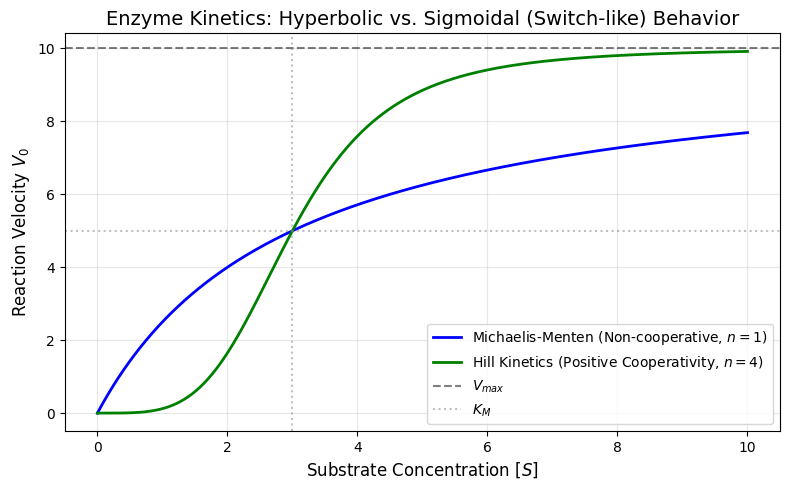

In [2]:
# Generate data for the two types of curves
S = np.linspace(0, 10, 500)
Vmax = 10
Km = 3

# Michaelis-Menten (Hyperbolic)
v_mm = Vmax * S / (Km + S)

# Hill Equation (Sigmoidal, n=4)
n = 4
v_hill = Vmax * (S**n) / (Km**n + S**n)

# Create the plot
plt.figure(figsize=(8, 5))
plt.plot(S, v_mm, label='Michaelis-Menten (Non-cooperative, $n=1$)', color='blue', linewidth=2)
plt.plot(S, v_hill, label=f'Hill Kinetics (Positive Cooperativity, $n={n}$)', color='green', linewidth=2)

# Add annotations
plt.axhline(Vmax, color='black', linestyle='--', alpha=0.5, label='$V_{max}$')
plt.axhline(Vmax/2, color='gray', linestyle=':', alpha=0.5)
plt.axvline(Km, color='gray', linestyle=':', alpha=0.5, label='$K_M$')

plt.title('Enzyme Kinetics: Hyperbolic vs. Sigmoidal (Switch-like) Behavior', fontsize=14)
plt.xlabel('Substrate Concentration $[S]$', fontsize=12)
plt.ylabel('Reaction Velocity $V_0$', fontsize=12)
plt.legend(loc='lower right', fontsize=10)
plt.grid(alpha=0.3)
plt.tight_layout()

# Save the plot
plt.savefig('cooperativity_graph.png', dpi=300)

***
#### **Part B**
Determine the kinetic parameters of the enzyme.

Below is a plot and python script that determines the kinetic parameters of the enzyme. They are:

  Vmax = 2.5098 ± 0.0514  M/min

  Km   = 1.6391 ± 0.1601  M

  n    = 4.1084 ± 0.7653  (Hill coefficient)
  
  R²   = 0.99744

      HILL KINETICS — FITTED PARAMETERS
  Vmax = 2.5098 ± 0.0514  M/min
  Km   = 1.6391 ± 0.1601  M
  n    = 4.1084 ± 0.7653  (Hill coefficient)
  R²   = 0.99744


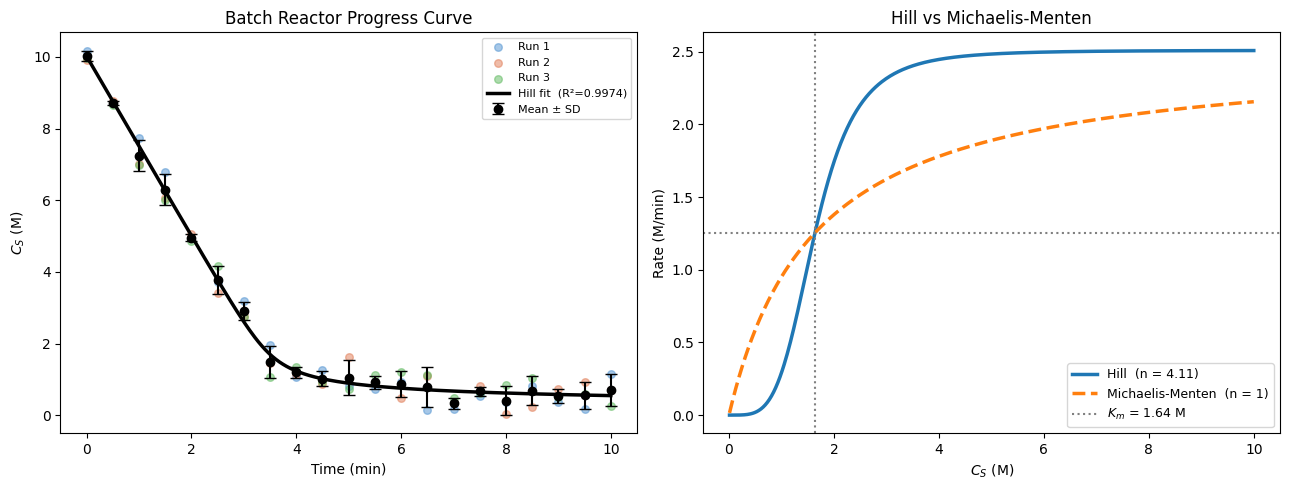

In [3]:
# 1. LOAD DATA
df = pd.read_excel("Enzyme data.xls")

t_data = df["Time (min)"].values
runs   = ["Cs_Run1 (M)", "Cs_Run2 (M)", "Cs_Run3 (M)"]

Cs_mean = df[runs].mean(axis=1).values
Cs_std  = df[runs].std(axis=1).values

# Stack all 3 runs for simultaneous fitting
t_all  = np.tile(t_data, 3)
Cs_all = np.concatenate([df[r].values for r in runs])

# Initial substrate concentration (average across runs at t=0)
Cs0 = df[runs].iloc[0].mean()

# 2. DEFINE ODE AND SIMULATION FUNCTION
# Batch reactor Hill kinetics:
#   -dCs/dt = Vmax * Cs^n / (Km^n + Cs^n)

def hill_ode(t, Cs, Vmax, Km, n):
    return [-Vmax * Cs[0]**n / (Km**n + Cs[0]**n)]

def simulate_Cs(t_eval, Cs0, Vmax, Km, n):
    sol = solve_ivp(
        hill_ode,
        t_span=[t_eval[0], t_eval[-1]],
        y0=[Cs0],
        args=(Vmax, Km, n),
        t_eval=t_eval,
        method="RK45",
        rtol=1e-8,
        atol=1e-10
    )
    return sol.y[0]

# 3. OBJECTIVE FUNCTION FOR curve_fit
# curve_fit passes (t_all, Vmax, Km, n) and expects Cs_all back.
# Since all 3 runs share the same t_data, we simulate once
# and tile the result to match all runs.

def model(t_stacked, Vmax, Km, n):
    Cs_sim = simulate_Cs(t_data, Cs0, Vmax, Km, n)
    return np.tile(Cs_sim, 3)

# 4. FIT — NONLINEAR LEAST SQUARES
p0     = [3.0,  2.0, 2.0]           # initial guesses: Vmax, Km, n
bounds = ([0.01, 0.01, 1.0],         # lower bounds
          [50.0, 20.0, 10.0])        # upper bounds

popt, pcov = curve_fit(
    model, t_all, Cs_all,
    p0=p0, bounds=bounds,
    maxfev=10000
)
perr = np.sqrt(np.diag(pcov))       # 1-sigma parameter uncertainties

Vmax_fit, Km_fit, n_fit = popt
Vmax_err, Km_err, n_err = perr

# 5. GOODNESS OF FIT (R²)
Cs_sim_fit = simulate_Cs(t_data, Cs0, Vmax_fit, Km_fit, n_fit)
ss_res = np.sum((Cs_mean - Cs_sim_fit)**2)
ss_tot = np.sum((Cs_mean - Cs_mean.mean())**2)
R2 = 1 - ss_res / ss_tot

# 6. RESULTS
print("=" * 45)
print("      HILL KINETICS — FITTED PARAMETERS")
print("=" * 45)
print(f"  Vmax = {Vmax_fit:.4f} ± {Vmax_err:.4f}  M/min")
print(f"  Km   = {Km_fit:.4f} ± {Km_err:.4f}  M")
print(f"  n    = {n_fit:.4f} ± {n_err:.4f}  (Hill coefficient)")
print(f"  R²   = {R2:.5f}")
print("=" * 45)

# 7. PLOT
t_fine   = np.linspace(0, t_data[-1], 300)
Cs_fine  = simulate_Cs(t_fine, Cs0, Vmax_fit, Km_fit, n_fit)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# --- Left: Progress curve fit ---
ax = axes[0]
colors = ["#4e91d0", "#e07b54", "#5cb85c"]
for i, run in enumerate(runs):
    ax.scatter(t_data, df[run].values, s=30, alpha=0.5,
               color=colors[i], label=f"Run {i+1}")
ax.errorbar(t_data, Cs_mean, yerr=Cs_std, fmt="ko",
            markersize=6, capsize=4, label="Mean ± SD", zorder=5)
ax.plot(t_fine, Cs_fine, "k-", linewidth=2.5,
        label=f"Hill fit  (R²={R2:.4f})")
ax.set_xlabel("Time (min)")
ax.set_ylabel("$C_S$ (M)")
ax.set_title("Batch Reactor Progress Curve")
ax.legend(fontsize=8)

# --- Right: Rate vs Cs (Hill vs MM) ---
ax = axes[1]
Cs_range  = np.linspace(0.01, 10, 500)
rate_hill = Vmax_fit * Cs_range**n_fit / (Km_fit**n_fit + Cs_range**n_fit)
rate_mm   = Vmax_fit * Cs_range         / (Km_fit         + Cs_range)

ax.plot(Cs_range, rate_hill, linewidth=2.5,
        label=f"Hill  (n = {n_fit:.2f})")
ax.plot(Cs_range, rate_mm,   linewidth=2.5, linestyle="--",
        label="Michaelis-Menten  (n = 1)")
ax.axvline(Km_fit, color="gray", linestyle=":", linewidth=1.5,
           label=f"$K_m$ = {Km_fit:.2f} M")
ax.axhline(Vmax_fit / 2, color="gray", linestyle=":", linewidth=1.5)
ax.set_xlabel("$C_S$ (M)")
ax.set_ylabel("Rate (M/min)")
ax.set_title("Hill vs Michaelis-Menten")
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig("hill_kinetics_fit.png", dpi=150, bbox_inches="tight")
plt.show()

***
## Problem 3

You are designing a cylindrical, capillary-based biosensor to continuously monitor the concentration of a specific metabolite (A). The capillary is extremely long (L=0.5 m). The entrance of the capillary (z=0) is submerged in a fluid stream that maintains a constant metabolite concentration of CA0​=10 mol/m3. The fluid within the capillary is completely stagnant and dilute. At the far end of the capillary (z=L), an engineered enzyme is immobilized uniformly across the flat circular base to catalyze the breakdown of A.

While characterizing this enzyme, you noticed a strange phenomenon. The enzyme possesses an unusually large active site volume. At higher concentrations, two molecules of A can simultaneously diffuse into and bind to the active site. However, this dual-bound orientation is sterically hindered and completely non-reactive, trapping the enzyme until one of the molecules dissociates.

The system parameters are:

- Diffusivity of A in the fluid (DA​): 2x10−6 m2/s
- Maximum surface reaction velocity (vmax​): 5x10−4 mol/(m2 s)
- Michaelis-Menten constant (KM​): 2 mol/m3
- Dissociation constant of the non-reactive dual-bound complex (KD​): 5 mol/m3

#### **Part A**
Based on the physical description of the active site, write the exact reaction rate expression (v​) for this immobilized enzyme as a function of the local concentration of A (CA​).

**Answer:**

The physical description of the enzyme shows two simultaneous phenomena: 

1. One molecule of A binds and reacts (which is standard Michaelis-Menten kinetics)
2. Another second moleucle of A binds the active occupied active site, forming a sterically hindered and completely non-reactive dead-end complex, governed by the dissociation constant $K_D$. 

These two phenomena shows the classical substrate inhibition kinetic model, where its rate expression is: 

$$v = \dfrac{v_{max} C_A}{K_M + C_A + \dfrac{C_A^2}{K_D}}$$

At low $C_A$ it behaves much like a regular Michaelis-Menten, but as $C_A$ increases, the $\frac{C_A^2}{K_D}$ term in the denominator grows and suppresses the rate. This means that the enzyme is increasingly trapped in the dead-end complex. 

***
#### **Part B**
Write the governing ordinary differential equation (ODE) that describes the concentration profile of A along the axial length (z) of the cylindrical capillary. Next, write the two boundary conditions required to solve this system. 

**Answer:**

Since the fluid inside the capillary is stagnant (meaning no convection) & dilute, and there is no reaction occuring within the volume of the fluid itself (due to the enzyme only being on the end surface), the transport of A is affected strictly by a 1D steady-state molecular diffusion. 

Applying Fick's Second Law for 1D diffusion with no volumetric generation gives the ODE: 
$$D_A \frac{d^2C_A}{dz^2} = 0 \implies \frac{d^2C_A}{dz^2} = 0$$

The two boundary conditions needed to solve this system are: 

BC1: At the entrance (z=0)  
The capillary is submerged in a stream that maintains a fixed, constant concentration of A. 
$$\text{BC1: at } z = 0, \quad C_A = C_{A0} = 10 \text{ mol/m}^3$$

BC2: At the far end (z=L)   
The rate at which molecules of A arrive at the surface by diffusion (aka diffusive flux) must perfectly balance the rate at which they are consumed by the immobilized enzyme reaction. By Fick's First Law,

$$-D_A \left. \frac{dC_A}{dz} \right|_{z=L} = \frac{v_{max} \cdot C_A(L)}{K_M + C_A(L) + \frac{C_A(L)^2}{K_D}}$$

Note for BC2: The reason that the sign is negative is b/c diffusion occurs in the positive z direction (down the capillary towards z=L), so therefore $\frac{dC_A}{dz} < 0$, and the negative sign ensures that the flux is positive (or directed towards the surface).

***
#### **Part C**
Plot the concentration profile CA​(z).

Below is the plot for the concentration profile CA(z).

       CONCENTRATION PROFILE SOLUTION
  CA(z=0)       = 10.0000  mol/m³  (BC1 ✓)
  CA(z=L)       = 0.17117  mol/m³
  Diffusive flux= 3.9315e-05  mol/(m²·s)
  Reaction rate = 3.9314e-05  mol/(m²·s)  (BC2 ✓)


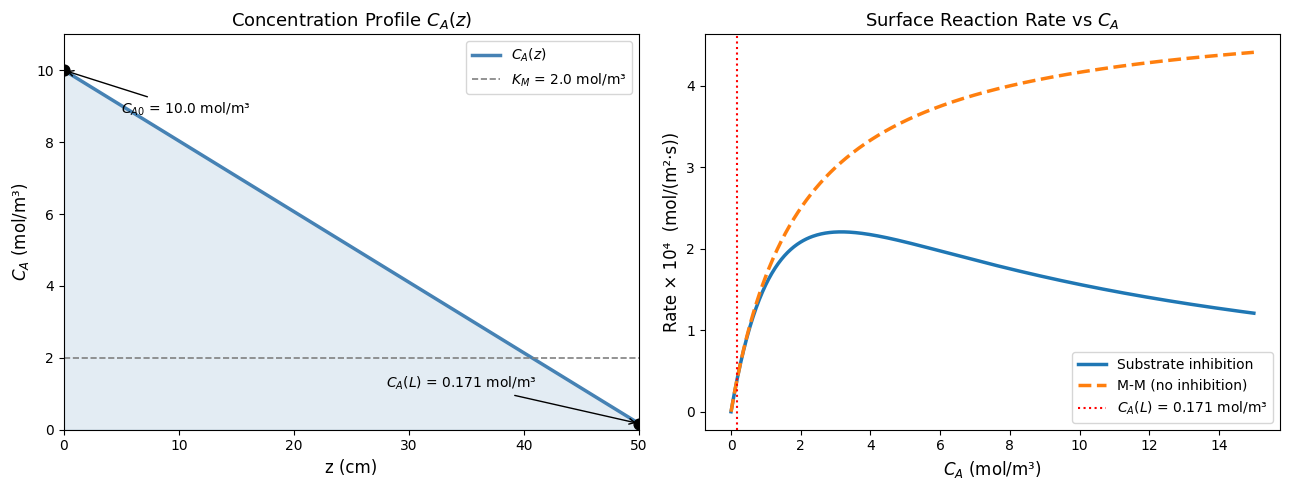

In [4]:
# 1. SYSTEM PARAMETERS
DA   = 2e-6   # m^2/s       — diffusivity of A
vmax = 5e-4   # mol/(m^2·s) — max surface reaction velocity
KM   = 2.0    # mol/m^3     — Michaelis-Menten constant
KD   = 5.0    # mol/m^3     — dual-binding dissociation constant
CA0  = 10.0   # mol/m^3     — inlet concentration (BC1)
L    = 0.5    # m           — capillary length

# 2. SURFACE REACTION RATE (substrate inhibition, Part A)
def rate(CA):
    return vmax * CA / (KM + CA + CA**2 / KD)

# 3. ODE SYSTEM
# d^2CA/dz^2 = 0  =>  rewrite as first-order system:
#   y[0] = CA       dy[0]/dz = y[1]
#   y[1] = dCA/dz   dy[1]/dz = 0

def ode_fun(z, y):
    return np.vstack([y[1],
                      np.zeros_like(y[0])])

# 4. BOUNDARY CONDITIONS
# BC1: CA(z=0) = CA0
# BC2: -DA * dCA/dz|_{z=L} = rate(CA(L))

def bc_fun(ya, yb):
    res_BC1 = ya[0] - CA0                   # CA at z=0
    res_BC2 = -DA * yb[1] - rate(yb[0])    # flux = reaction at z=L
    return np.array([res_BC1, res_BC2])

# 5. SOLVE BVP
z_mesh = np.linspace(0, L, 200)

# Initial guess: linear profile from CA0 to ~0
y_init      = np.zeros((2, z_mesh.size))
y_init[0]   = CA0 * (1 - z_mesh / L)
y_init[1]   = -CA0 / L

sol = solve_bvp(ode_fun, bc_fun, z_mesh, y_init, tol=1e-8, max_nodes=10000)

if sol.status != 0:
    raise RuntimeError(f"Solver failed: {sol.message}")

CA_sol = sol.y[0]
z_sol  = sol.x

# 6. PRINT KEY RESULTS
CA_L   = sol.y[0, -1]
flux_L = -DA * sol.y[1, -1]
print("=" * 45)
print("       CONCENTRATION PROFILE SOLUTION")
print("=" * 45)
print(f"  CA(z=0)       = {sol.y[0,0]:.4f}  mol/m³  (BC1 ✓)")
print(f"  CA(z=L)       = {CA_L:.5f}  mol/m³")
print(f"  Diffusive flux= {flux_L:.4e}  mol/(m²·s)")
print(f"  Reaction rate = {rate(CA_L):.4e}  mol/(m²·s)  (BC2 ✓)")
print("=" * 45)

# 7. PLOT
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# --- Left: CA(z) profile ---
ax = axes[0]
ax.plot(z_sol * 100, CA_sol, linewidth=2.5, color='steelblue', label='$C_A(z)$')
ax.fill_between(z_sol * 100, CA_sol, alpha=0.15, color='steelblue')
ax.axhline(KM, color='gray', linestyle='--', linewidth=1.2,
           label=f'$K_M$ = {KM} mol/m³')
ax.scatter([0, L*100], [CA0, CA_L], color='black', zorder=5, s=60)
ax.annotate(f'$C_{{A0}}$ = {CA0} mol/m³', xy=(0, CA0),
            xytext=(5, CA0 - 1.2), fontsize=10,
            arrowprops=dict(arrowstyle='->', color='black'))
ax.annotate(f'$C_A(L)$ = {CA_L:.3f} mol/m³', xy=(L*100, CA_L),
            xytext=(28, CA_L + 1.0), fontsize=10,
            arrowprops=dict(arrowstyle='->', color='black'))
ax.set_xlabel('z (cm)', fontsize=12)
ax.set_ylabel('$C_A$ (mol/m³)', fontsize=12)
ax.set_title('Concentration Profile $C_A(z)$', fontsize=13)
ax.set_xlim(0, 50)
ax.set_ylim(0, 11)
ax.legend(fontsize=10)

# --- Right: Rate vs CA (substrate inhibition curve) ---
ax2 = axes[1]
CA_range = np.linspace(0, 15, 500)
r_inhibition = rate(CA_range)
r_mm         = vmax * CA_range / (KM + CA_range)   # no inhibition

ax2.plot(CA_range, r_inhibition * 1e4, linewidth=2.5, label='Substrate inhibition')
ax2.plot(CA_range, r_mm * 1e4,         linewidth=2.5, linestyle='--', label='M-M (no inhibition)')
ax2.axvline(CA_L, color='red', linestyle=':', linewidth=1.5,
            label=f'$C_A(L)$ = {CA_L:.3f} mol/m³')
ax2.set_xlabel('$C_A$ (mol/m³)', fontsize=12)
ax2.set_ylabel('Rate × 10⁴  (mol/(m²·s))', fontsize=12)
ax2.set_title('Surface Reaction Rate vs $C_A$', fontsize=13)
ax2.legend(fontsize=10)

plt.tight_layout()
plt.savefig("capillary_biosensor_profile.png", dpi=150, bbox_inches="tight")
plt.show()

## Problem 4

You are analyzing a simple synthetic gene circuit engineered into E. coli. The circuit utilizes the lac promoter (Plac​) to control the transcription and subsequent translation of green fluorescent protein (GFP).
There are three key regulatory species in this system:

- RNA Polymerase (RNAP): Binds to the free promoter to initiate transcription. You may assume it acts as a single entity with a stoichiometric coefficient of 1. Its total concentration in the cell is constant.
- Lac Repressor (LacI): Binds to the promoter to block RNAP, actively repressing GFP transcription. Its total concentration in the cell is constant.
- Inducer (I): A small molecule added to the environment. When the inducer binds to LacI, it alters the repressor's conformation, converting it into an inactive species that can no longer bind to the promoter.
Recall from class that in the generalized model of transcription, complex formation is extremely rapid and is essentially at equilibrium compared to the slower processes of transcription and translation.

#### **Part A**
Write out the three distinct chemical equations that dictate the formation of complexes in this system. Clearly label the Active/ON state and the Repressed/OFF states.

**Answer:**

Note: Let P mean the free promoter, R mean the free Lac repressor (LacI), I mean the inducer, and Q denote RNAP.

1. Reaction 1: Active/ON state 
- RNAP binds to P; transcription occurs.
$$P + Q \underset{k_{-1}}{\stackrel{k_{+1}}{\rightleftharpoons}} PQ 
\qquad K_{Q} = \frac{[P][Q]}{[PQ]}$$

2. Reaction 2: Repressed/OFF state
- R binds P; Q is blocked.
$$P + R \underset{k_{-2}}{\stackrel{k_{+2}}{\rightleftharpoons}} PR 
\qquad K_{R} = \frac{[P][R]}{[PR]}$$

3. Reaction 3: Inducer (I) inactivates repressor (LacI, R)
- I binds R, forming an inactive complex; conformational change; R can no longer bind to P.
$$R + I \underset{k_{-3}}{\stackrel{k_{+3}}{\rightleftharpoons}} RI 
\qquad K_{I} = \frac{[R][I]}{[RI]}$$

***
#### **Part B**
Using the equilibrium equations you developed in Part A, conceptually explain the step-by-step mechanism by which the addition of the inducer to the cell culture leads to an increase in the concentration of GFP. Write the differential equations for the system but do not solve them.

**Answer:**

Step-by-step mechanism:

1. Inducer $[I]$ increases in the culture medium and diffuses into the cell
2. Free inducer binds free LacI repressor via Reaction 3, forming the inactive $RI$ complex
3. As free $[R]$ is depleted, the $PR$ complex (Reaction 2) dissociates to restore equilibrium; the promoter is progressively freed
4. With more free promoter $[P]$ available, RNAP binds more frequently (Reaction 1), forming more $PQ$ complex
5. Each $PQ$ complex initiates transcription, producing GFP mRNA, which is subsequently translated into GFP protein

Since complex formation is fast relative to transcription and translation, the complexes $[PQ]$, $[PR]$, and $[RI]$ are treated as quasi-static equilibria. The dynamic equations governing the slow processes are:

$$\frac{d[\text{mRNA}]}{dt} = \alpha \cdot [PQ] - \delta_m [\text{mRNA}]$$

$$\frac{d[\text{GFP}]}{dt} = \beta \cdot [\text{mRNA}] - \delta_p [\text{GFP}]$$

where:
- $\alpha$ is the transcription rate constant
- $\beta$ is the translation rate constant  
- $\delta_m$ is the mRNA degradation rate constant
- $\delta_p$ is the GFP degradation/dilution rate constant

The promoter occupancy $[PQ]$ is determined by solving the three equilibrium expressions alongside the conservation constraints:

$$P_T = [P] + [PQ] + [PR]$$

$$R_T = [R] + [PR] + [RI]$$

$$Q_T = [Q] + [PQ]$$

***
#### **Part C**
You conduct an experiment where you continually increase the concentration of the inducer in the culture medium, measuring the resulting steady-state GFP fluorescence. You observe that eventually, the GFP signal stops increasing and plateaus at a maximum ceiling, even when massive amounts of additional inducer are added. Using the physical constraints of the cell and the building blocks of this circuit, explain why the system reaches this ceiling.

**Answer:**

Even with infinite inducer, three physical constraints impose a hard ceiling on GFP output:

1. Finite promoter copy number  

- There is only a fixed number of $P_{lac}$ copies per cell. Once every promoter is occupied by RNAP — i.e., $[PQ] = P_T$ — adding more inducer cannot increase transcription further. The promoter is fully saturated.

2. Finite RNAP pool

- At very high $[I]$, essentially all repressor exists as $RI$, so $[PR] \approx 0$ and the promoter is fully free. The maximum $[PQ]$ is then limited by the total RNAP pool $Q_T$, which is constant and shared across all promoters in the cell.

3. Downstream translational and degradation limits  

- Even if mRNA production is maximized, ribosomes (also finite) cap the translation rate.

At steady state, the maximum achievable GFP concentration is:

$$[\text{GFP}]_{\max} = \frac{\beta \cdot [\text{mRNA}]_{\max}}{\delta_p} = \frac{\beta}{\delta_p} \cdot \frac{\alpha \cdot P_T}{\delta_m}$$

This ceiling is set entirely by $P_T$, $Q_T$, ribosome availability, and the degradation rates — none of which are functions of inducer concentration. Adding more inducer beyond complete repressor sequestration has no further effect because the bottleneck has shifted to these inducer-independent constraints.

## Problem 5

You are analyzing the diffusion of metabolite A through a dilute, aqueous rectangular container that is L=0.5 m long. The system is at steady state and there is no bulk fluid flow. The wall at the entrance (x=0) is completely coated with solid metabolite A, which dissolves into the adjacent liquid, maintaining a constant local liquid concentration of CA0​=1.5 mol/m3. As metabolite A diffuses in the x-direction through the container, it is continuously consumed by an enzyme that is dissolved uniformly throughout the entire liquid volume.

The dissolved enzyme follows Michaelis-Menten kinetics with the following parameters:
- Maximum volumetric reaction velocity (vmax​): 2x10−3 mol/(m3 s)
- Michaelis-Menten constant (KM​): 75 mol/m3
- Diffusivity of A in the liquid (DA​): 1.2×10−6 m2/s

Because the enzyme is highly active, metabolite A exhibits low penetration into the container.

#### **Part A**
Derive the governing differential equation that describes the concentration profile CA​(x) along the length of the container. Next, explicitly state the two boundary conditions required to solve this system.

**Answer:**

The system involves 1D steady-state diffusion with homogeneous volumetric consumption by the dissolved enzyme. Thefore, there is no bulk flow. Applying a mass balance on a differential slab of thickness $dx$:

$$\text{(flux in)} - \text{(flux out)} - \text{(reaction consumed)} = 0$$

Using Fick's First Law for the diffusive flux and Michaelis-Menten kinetics for the reaction term, and invoking steady state ($\partial C_A / \partial t = 0$):

$$D_A \frac{d^2 C_A}{dx^2} - \frac{v_{\max} C_A}{K_M + C_A} = 0$$

The problem states that metabolite A has low penetration — meaning $C_A \ll K_M$ throughout the container. With:
$$C_{A0} = 1.5 \ \text{mol/m}^3$$ 
$$K_M = 75 \ \text{mol/m}^3$$
 
we have $C_A \ll K_M$ everywhere, so:

$$\frac{v_{\max} C_A}{K_M + C_A} \approx \frac{v_{\max}}{K_M} C_A = k \cdot C_A
\qquad \text{where } k = \frac{v_{\max}}{K_M}$$

The ODE simplifies to a linear second-order ODE:

$$D_A \frac{d^2 C_A}{dx^2} - k \cdot C_A = 0$$

Boundary Conditions:

BC1: At the entrance ($x = 0$), the wall maintains a constant dissolved concentration:

$$C_A(x=0) = C_{A0} = 1.5 \ \text{mol/m}^3$$

BC2: At the far end ($x = L$), the wall is impermeable — no metabolite passes through,
so the diffusive flux is zero:

$$\left. \frac{dC_A}{dx} \right|_{x=L} = 0$$

***
#### **Part B**
What is the concentration of metabolite A at a depth of exactly 10 cm into the container?

**Answer:**

The linearized ODE $D_A C_A'' - k C_A = 0$ has the general solution:

$$C_A(x) = A \cosh(\lambda x) + B \sinh(\lambda x)
\quad \text{where } \lambda = \sqrt{\frac{k}{D_A}} = \sqrt{\frac{v_{\max}}{K_M D_A}}$$

Applying the two boundary conditions:

- BC1: $C_A(0) = C_{A0} \Rightarrow A = C_{A0}$
- BC2: $C_A'(L) = 0 \Rightarrow B = -C_{A0} \tanh(\lambda L)$

This simplifies to the closed-form solution:

$$C_A(x) = C_{A0} \cdot \frac{\cosh\!\left[\lambda(L - x)\right]}{\cosh(\lambda L)}$$

Substituting the parameter values:

$$k = \frac{v_{\max}}{K_M} = \frac{2 \times 10^{-3}}{75} = 2.667 \times 10^{-5} \ \text{s}^{-1}$$

$$\lambda = \sqrt{\frac{k}{D_A}} = \sqrt{\frac{2.667 \times 10^{-5}}{1.2 \times 10^{-6}}}
= 4.714 \ \text{m}^{-1}$$

At $x = 0.10 \ \text{m}$:

$$C_A(0.10) = 1.5 \cdot \frac{\cosh\!\left[4.714 \times (0.5 - 0.1)\right]}{\cosh(4.714 \times 0.5)}$$

$$C_A(0.10) = 1.5 \cdot \frac{\cosh(1.8856)}{\cosh(2.357)}$$

$$C_A(0.10 \ \text{m}) \approx 0.949 \ \text{mol/m}^3$$

This result confirms the low-penetration behavior: even at only 10 cm depth (20% of $L$), the concentration has already dropped from $1.5$ to $0.949 \ \text{mol/m}^3$, driven by the continuous enzymatic consumption throughout the volume.

## Problem 6

Acetylcholine plays a critical role at the neuromuscular junction during mechanotransduction. The enzyme responsible for breaking down this neurotransmitter in the human body is acetylcholinesterase (AChE), and its classic competitive inhibitor is the drug donepezil.

***
#### **Part A**
Navigate to UniProt and find the canonical entry for human acetylcholinesterase. What is its exact UniProtKB Entry ID, and how many amino acids comprise the full-length canonical sequence?

The UniProtKB Entry ID is `P22303` and its full-length canonical sequence comprises of 614 amino acids.

***
#### **Part B**
Navigate to the PubChem database and search for donepezil. Report its PubChem CID, its computed molecular weight (to one decimal place), and the number of hydrogen bond acceptors it possesses.

The PubChem CID for donepezil is `3152`, its computed molecular weight is 379.5 g/mol, and it possesses 4 hydrogen bond acceptors.

***
#### **Part C**
Navigate to the Protein Data Bank (PDB). Search for a crystal structure of human AChE bound to donepezil. Identify the PDB ID that provides the highest resolution for this complex.

The PDB ID that provides the highest resolution for the complex is `4EY7`, with a resolution of 2.35 Å.

***
#### **Part D**
List the exact amino acid residues (name and chain number) that are form hydrogen bonds with donepezil in the active site of AChE.

The exact amino acid residue that form a hydrogen bond with donepezil in the active site of AChE is `Phe295` (amino acid lokcated in the acyl pocket of the AChE active site gorge). Docking simulations, which predict energetically favorable binding poses via computation, will also report hydrogen bonding to `Ser203`/`His447` because the catalytic triad is the most electrostatically active region in the active site. However, X-ray crystallography (which is much more accurate) shows that donepezil doesnt reach far enough to directly H-bond the triad, but does show `Phe295` being able to H-bond. 

***
#### **Part E**
List the exact amino acid residues that are shown forming pi-pi stacking with donepezil.

The exact amino acid residues that are shown forming pi-pi stacking with donepezil are `Trp86` (forms a strong parallel, face-to-face pi-pi stacking interaction w/ the indanone ring of donepezil at the Peripheral Anionic Site (PAS) near the gorge entrance) and `Trp286` (Forms a classic pi-pi stacking interaction with the benzyl ring of donepezil deep inside the Catalytic Anionic Site (CAS)). 

***
#### **Part F**
Would you rely on a chatbot to answer parts D & E. Why or why not?

No, I wouldn't rely on a chatbot to answer parts D & E. This is because although chatbots can help expedite the process of finding the amino acid residues that either form H-bonds with donepezil or form pi-pi stacking with donepezil, they rely on the general knowledge that is given to them, some of which can be taken out of context, or ignored entirely. For example, in part D, some chatbots (like Claude) said that `Ser203` and `His447` formed H-bonds, but after looking further into it, I realized that those amino acids were only predicted to by simulations, and that X-ray crystallography showed that they actually didn't, which meant that Claude took some docking simulation studies out of context. 